# 環境檢查

**從上到下按 Run > Run All Cells，跑完看最後那張總表。全部通過就可以開始上課。**

- 這一包放在桌面，而且 **JupyterLab 要在 week6 這個資料夾裡打開**: 終端機先 `conda activate aiops-anomaly-zero-to-hero`，再 `cd` 進來，再打 `jupyter lab`。不在這個資料夾開，兩本 lab 讀不到 `data/`。
- **先 activate 再開 JupyterLab，這一步不能跳過。** 從別的環境開 Jupyter 再挑這個 kernel 的話，Windows 上一畫圖 kernel 就會直接死掉 (畫面只寫 Kernel died，不會說原因) 。下一格之後如果在畫中文圖那一格斷掉，原因就是這個: 關掉 JupyterLab，照上面那一行重開。
- 課堂順序: `1_pkg_checker.ipynb` → `2_lab06_forecasting.ipynb` → `3_lab07_root_cause_analysis.ipynb` → 終端機打 `python 4_grafana.py`。
- 課程環境的名字是 `aiops-anomaly-zero-to-hero`。缺的套件下一格會直接裝起來，裝不動的時候它會寫出改用 conda 的做法。
- 最後一步的 Grafana 要用 Docker Desktop，請先把它打開。

In [1]:
# 🎯 讀這台機器對應的環境檔，把缺的套件裝起來，再印出每一個套件的版本。

# ---- 1. 內建函式庫、這一本共用的三個小工具，以及關掉套件的雜訊訊息 ----
#         CHECKS 收每一項檢查的結果，最後一格再把它排成總表。
from pathlib import Path
from importlib import metadata
from IPython.display import display
import importlib
import logging
import platform
import re
import sys
import warnings

CHECKS = []


def record(item, status, detail, fix=""):
    """把一項檢查的結果加進 CHECKS。狀態只有三種: 通過 / 失敗 / 注意。"""
    CHECKS.append({"檢查項目": item, "狀態": status,
                   "實際結果": str(detail), "沒過的話怎麼辦": fix})
    return status, detail


def safe(item, func, fix=""):
    """跑一項檢查，並且保證它出錯的時候這一格不會中斷，只會在總表多一列失敗。"""
    try:
        status, detail = func()
    except Exception as exc:
        status, detail = "失敗", f"{type(exc).__name__}: {exc}"
    return record(item, status, detail, fix)


def show_table(rows, columns):
    """把幾列資料排成一張表。pandas 有可能是這一格才剛裝好的，所以在函式裡面才 import。"""
    try:
        import pandas as pd
        pd.set_option("display.max_colwidth", 200)   # 不設的話「怎麼辦」那一欄會被截掉
        pd.set_option("display.width", 200)
        display(pd.DataFrame(rows, columns=columns))
    except Exception:
        print(" | ".join(columns))
        for row in rows:
            print(" | ".join(str(x) for x in row))


# Prophet 與它的後端 cmdstanpy 在 import 時會印出好幾行訊息與提示，先關掉，表格才看得清楚
# (兩本 lab 的第一格做的是同一件事)。
warnings.filterwarnings("ignore")
for _log_name in ("cmdstanpy", "prophet", "stan"):
    _lg = logging.getLogger(_log_name)
    _lg.setLevel(logging.CRITICAL)
    _lg.handlers.clear()
    _lg.addHandler(logging.NullHandler())
    _lg.propagate = False

# ---- 2. 這台機器要用哪一份環境檔，week6 資料夾在哪裡 ----
#         這門課只支援 macOS 與 Windows，兩份環境檔差一個 pywin32。
ENV_NAME = "aiops-anomaly-zero-to-hero"
OS_LABEL = {"Darwin": "macOS", "Windows": "Windows"}.get(platform.system(), platform.system())
ENV_YML = {"macOS": "environment.macos.yml", "Windows": "environment.windows.yml"}.get(OS_LABEL)

# 從現在的資料夾往上走，找到帶著 environments/ 的那一層，那一層就是 week6。
# 兩本 lab 找 data/ 用的是同一套走法，所以這裡算出來的位置跟它們一定一致。
WEEK6_DIR = Path.cwd()
while WEEK6_DIR != WEEK6_DIR.parent and not (WEEK6_DIR / "environments").is_dir():
    WEEK6_DIR = WEEK6_DIR.parent
if not (WEEK6_DIR / "environments").is_dir():
    WEEK6_DIR = Path.cwd()

if ENV_YML is None:
    FIX_CONDA = f"這門課只支援 macOS 與 Windows，這台機器是 {platform.system()}，請換一台上課"
    record("作業系統", "失敗", f"{platform.system()} 沒有對應的環境檔", FIX_CONDA)
else:
    # Windows 的路徑分隔符號是反斜線，這一行直接寫成學生可以照打的樣子。
    _yml_path = f"environments\\{ENV_YML}" if OS_LABEL == "Windows" else f"environments/{ENV_YML}"
    FIX_CONDA = (f"開 Anaconda Prompt (macOS 開終端機)，cd 到 week6 資料夾，"
                 f"跑 conda activate {ENV_NAME}，再跑 conda env update -f {_yml_path} "
                 f"(不要加 --prune，那會把別的 lab 需要的套件刪掉)")

record("Python 版本", "通過" if sys.version_info[:2] >= (3, 10) else "失敗",
       f"Python {platform.python_version()}", FIX_CONDA)

show_table([
    ("作業系統", platform.platform()),
    ("Python 版本", platform.python_version()),
    ("Python 直譯器", sys.executable),
    ("week6 資料夾", str(WEEK6_DIR)),
    ("這台機器該用的環境檔", f"environments/{ENV_YML}" if ENV_YML else "沒有，只支援 macOS 與 Windows"),
], ["項目", "這台機器"])

# ---- 3. 從環境檔讀出套件清單，逐一 import 看缺哪些 ----
#         安裝時打的名字跟 import 時打的名字不一定一樣，CONDA_TO_IMPORT 就是在對照這件事;
#         python 與 pip 不是拿來 import 的東西，跳過。
CONDA_TO_IMPORT = {"scikit-learn": "sklearn", "ipython": "IPython", "pywin32": "win32api"}
NOT_A_PACKAGE = {"python", "pip"}


def parse_env_yml(path):
    """拆成 (conda 名字, 帶版本條件的完整字串)。刻意不用 yaml 套件: 讀環境檔的時候還不能假設有第三方套件。"""
    specs, inside = [], False
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.split("#", 1)[0].rstrip()                # 砍掉註解
        if line.startswith("dependencies:"):
            inside = True
            continue
        if inside and line and not line.startswith(" "):    # 回到最外層就代表這一段結束
            break
        if inside and line.strip().startswith("- "):
            spec = line.strip()[2:].strip()
            # 套件名字是第一個版本符號之前的那一段，例如 scikit-learn>=1.4,<2 的 scikit-learn。
            name = re.split(r"[=<>!~]", spec, maxsplit=1)[0].strip()
            if name and name not in NOT_A_PACKAGE:
                specs.append((name, spec))
    return specs


_env_path = (WEEK6_DIR / "environments" / ENV_YML) if ENV_YML else None
if _env_path is not None and _env_path.is_file():
    SPECS = parse_env_yml(_env_path)
else:
    SPECS = []
    record("環境檔在不在", "失敗", f"找不到 {_env_path}",
           "確認 JupyterLab 是在 week6 資料夾裡打開的，而且 environments/ 這個資料夾還在")


def missing_now():
    """回傳現在 import 不進來的那幾個 (conda 名字, 完整字串)。"""
    out = []
    for name, spec in SPECS:
        try:
            importlib.import_module(CONDA_TO_IMPORT.get(name, name))
        except Exception:
            out.append((name, spec))
    return out


MISSING = missing_now()

# ---- 4. 缺的直接用 pip 裝起來 ----
#         spec 兩邊一定要加引號: 版本條件裡的 > 沒加引號會被命令列當成「把輸出寫進檔案」。
#         包在 try 裡面，是為了萬一 pip 自己丟出例外，後面的檢查還要繼續跑。
if MISSING:
    print("這台機器缺這幾個，現在裝: " + "、".join(name for name, _ in MISSING))
else:
    print("全部都在，不用裝。")

for pkg_name, pkg_spec in MISSING:
    try:
        %pip install --quiet "{pkg_spec}"
    except Exception as exc:
        print(f"{pkg_name} 裝的時候出錯: {type(exc).__name__}: {exc}")

importlib.invalidate_caches()        # 剛裝好的套件要重掃一次，這個 kernel 才 import 得到
STILL_MISSING = missing_now() if MISSING else []

if STILL_MISSING:
    print("\n用 pip 裝不起來的: " + "、".join(name for name, _ in STILL_MISSING))
    if OS_LABEL == "Windows" and any(name == "prophet" for name, _ in STILL_MISSING):
        print("prophet 在 Windows 上用 pip 裝要先編譯，裝不起來多半卡在這一步。")
    print("請改用 conda 裝: " + FIX_CONDA)
    print("裝完關掉 JupyterLab 重開，再跑一次這一本。")
elif MISSING:
    print("\n裝好了。請按 Kernel > Restart Kernel，再從第一格重跑一次，新裝的套件才吃得到。")

# ---- 5. 印出每一個套件的版本 ----
rows = []
for name, spec in SPECS:
    import_name = CONDA_TO_IMPORT.get(name, name)

    def check_import(import_name=import_name, name=name):
        module = importlib.import_module(import_name)
        # 大多數套件有 __version__；沒有的 (例如 prometheus_client) 就去查已安裝套件的中繼資料。
        return "通過", str(getattr(module, "__version__", None) or metadata.version(name))

    status, detail = safe(f"套件 {name}", check_import, FIX_CONDA)
    rows.append((name, import_name, status, detail))

show_table(rows, ["環境檔上的名字", "import 時打的名字", "狀態", "版本或錯誤訊息"])

,項目,這台機器
0,作業系統,Windows-11-10.0.22631-SP0
1,Python 版本,3.12.13
2,Python 直譯器,E:\Miniconda3\envs\aiops-anomaly-zero-to-hero\python.exe
3,week6 資料夾,E:\桌面\agent_os\database\NTU_POLab\AIAxMitake\github_code\aiops-anomaly-zero-to-hero\week6
4,這台機器該用的環境檔,environments/environment.windows.yml


全部都在，不用裝。

,環境檔上的名字,import 時打的名字,狀態,版本或錯誤訊息
0,numpy,numpy,通過,2.5.2
1,pandas,pandas,通過,3.0.5
2,scipy,scipy,通過,1.18.0
3,matplotlib,matplotlib,通過,3.11.1
4,prophet,prophet,通過,1.4.0
5,scikit-learn,sklearn,通過,1.9.0
6,statsmodels,statsmodels,通過,0.14.6
7,networkx,networkx,通過,3.6.1
8,prometheus_client,prometheus_client,通過,0.26.0
9,jupyterlab,jupyterlab,通過,4.6.3



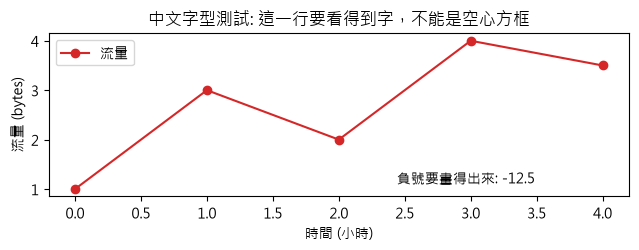

,項目,狀態,實際結果
0,matplotlib 畫得出中文,通過,用的是 Microsoft JhengHei，請確認上面那張圖是中文字


In [2]:
# 🎯 找一個中文字型設給 matplotlib，畫一張中文圖，請用眼睛確認圖上是中文字不是空心方框。

# ---- 1. 畫圖要用的東西，以及這一本顯示圖的方式 ----
import base64
import io
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm
from IPython.display import HTML


def show_fig(fig, width="80%"):
    """把圖存成 PNG，再以 80% 寬度置中顯示，然後關掉它。

    直接 display(fig) 會靠左，寬度也只由 figsize 決定; 轉成 <img> 才控制得了寬度與置中。
    """
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=fig.dpi, bbox_inches="tight")
    plt.close(fig)
    src = "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("ascii")
    display(HTML(f'<div style="text-align: center">'
                 f'<img src="{src}" style="width: {width}"></div>'))


# ---- 2. 找一個裝得到的中文字型設給 matplotlib ----
#         作業系統內建的中文字型名稱不一樣，由左到右試，用第一個裝得到的
#         (這份候選清單跟兩本 lab 第一格用的完全相同)。
CJK_CANDIDATES = ["PingFang TC", "PingFang HK", "Heiti TC", "Arial Unicode MS",   # macOS
                  "Microsoft JhengHei", "Microsoft YaHei",                        # Windows
                  "Noto Sans CJK TC", "Noto Sans TC", "Source Han Sans TW",
                  "WenQuanYi Zen Hei", "Droid Sans Fallback"]
FONT_FIX = {
    "macOS": "系統內建 PingFang TC。找不到的話先刪掉字型快取資料夾 ~/.matplotlib 再重跑一次",
    "Windows": "系統內建微軟正黑體 Microsoft JhengHei。找不到的話先刪掉字型快取資料夾 "
               "%USERPROFILE%\\.matplotlib 再重跑一次",
}.get(OS_LABEL, "裝一套中文字型，再刪掉 matplotlib 的字型快取資料夾重跑一次")

_installed = {f.name for f in _fm.fontManager.ttflist}
CJK_FONT = next((name for name in CJK_CANDIDATES if name in _installed), None)
if CJK_FONT:
    plt.rcParams["font.sans-serif"] = [CJK_FONT] + plt.rcParams["font.sans-serif"]
    # 中文字型多半沒有獨立的粗體檔，matplotlib 會為每一次粗體字送出一行提示，關掉。
    logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams["axes.unicode_minus"] = False     # 用 ASCII 的減號，中文字型才畫得出負號

# ---- 3. 畫一張中文圖，這一項要你自己用眼睛看 ----
#         版本號跟檔案在不在可以用程式判斷，字有沒有真的被畫出來不行。
fig, ax = plt.subplots(figsize=(6.6, 2.6))
ax.plot([0, 1, 2, 3, 4], [1.0, 3.0, 2.0, 4.0, 3.5], color="tab:red", marker="o", label="流量")
ax.set_title("中文字型測試: 這一行要看得到字，不能是空心方框")
ax.set_xlabel("時間 (小時)")
ax.set_ylabel("流量 (bytes)")
ax.legend(loc="upper left")
# transform=ax.transAxes 的意思是這一行字用「圖框的比例」定位，0.60 與 0.08 就是
# 從左邊算 60%、從下面算 8% 的地方，不會壓到上面那條線。
ax.text(0.60, 0.08, "負號要畫得出來: -12.5", transform=ax.transAxes)
fig.tight_layout()
show_fig(fig)

record("matplotlib 畫得出中文",
       "通過" if CJK_FONT else "失敗",
       f"用的是 {CJK_FONT}，請確認上面那張圖是中文字" if CJK_FONT
       else "候選清單裡的中文字型一個都沒裝到，上面那張圖的中文會是空心方框",
       FONT_FIX)
show_table([(CHECKS[-1]["檢查項目"], CHECKS[-1]["狀態"], CHECKS[-1]["實際結果"])],
           ["項目", "狀態", "實際結果"])

In [3]:
# 🎯 讀課程的三份 CSV，確認列數、欄數與時間範圍都對得上。

# ---- 1. 三份檔案，以及這一版教材裡它們應該長什麼樣子 ----
#         列數欄數對不上，通常是用 Excel 開過再存檔，或是下載中斷留下半個檔案。
import pandas as pd

DATA_DIR = WEEK6_DIR / "data" / "synthetic"
DATA_FILES = [
    ("synthetic_rrd_metrics_week6.csv", "指標檔: 五個 port、一整個月、每 5 分鐘一列", 43200, 21),
    ("synthetic_event_catalog_week6.csv", "事件目錄: 每一次注入的事件在哪個 port、從何時到何時", 17, 7),
    ("synthetic_scheduled_calendar_week6.csv", "排程行事曆: 開盤微爆、收盤集合競價、日終對帳", 107, 7),
]
FIX_DATA = ("先確認 JupyterLab 是在 week6 資料夾裡打開的 (終端機 cd 進 week6 再打 jupyter lab)，"
            "再確認 data/synthetic/ 底下三份 CSV 都在，缺的話重新下載一次整包教材")

# ---- 2. 逐一讀進來，跟預期的列數欄數比對 ----
def read_one(path, rows_expected, cols_expected):
    if not path.is_file():
        return "失敗", f"找不到 {path}"
    table = pd.read_csv(path)
    detail = f"{len(table):,} 列 {table.shape[1]} 欄"
    if "timestamp" in table.columns:      # 只有指標檔有時間欄，順便報時間範圍與 port 個數
        stamps = pd.to_datetime(table["timestamp"])
        detail += (f"，{stamps.min():%Y-%m-%d %H:%M} 到 {stamps.max():%Y-%m-%d %H:%M}"
                   f"，{table['port_id'].nunique()} 個 port")
    if (len(table), table.shape[1]) != (rows_expected, cols_expected):
        return "失敗", f"{detail}，但這一版教材應該是 {rows_expected:,} 列 {cols_expected} 欄"
    return "通過", detail


# ---- 3. 印出結果 ----
rows = []
for filename, purpose, n_rows, n_cols in DATA_FILES:
    # 預設參數 p=... 的用意是把這一圈的值固定住，不然函式要到 safe() 裡面才執行，
    # 會拿到迴圈最後一圈的值。
    status, detail = safe(f"資料 {filename}",
                          lambda p=DATA_DIR / filename, r=n_rows, c=n_cols: read_one(p, r, c),
                          FIX_DATA)
    rows.append((filename, status, detail, purpose))

show_table(rows, ["檔名", "狀態", "實際結果", "這一份是什麼"])

,檔名,狀態,實際結果,這一份是什麼
0,synthetic_rrd_metrics_week6.csv,通過,"43,200 列 21 欄，2026-02-01 00:00 到 2026-03-02 23:55，5 個 port",指標檔: 五個 port、一整個月、每 5 分鐘一列
1,synthetic_event_catalog_week6.csv,通過,17 列 7 欄,事件目錄: 每一次注入的事件在哪個 port、從何時到何時
2,synthetic_scheduled_calendar_week6.csv,通過,107 列 7 欄,排程行事曆: 開盤微爆、收盤集合競價、日終對帳


In [4]:
# 🎯 檢查 docker 指令、Docker 背景服務，以及 4_grafana.py 要用的四個 host port。

# ============ ⚙️ 可調參數 ============
# WEEK6_PORTS: 跟 4_grafana.py 的 DEFAULT_PORTS 是同一組，改了要兩邊一起改。被佔住的時候
#              不用動這裡，改 infra/stack/.env 就好。兩支重播程式各佔一個:
#              8011 重播 Lab 06 的那兩晚，8010 重播 Lab 07 的事故 L。
# DOCKER_TIMEOUT: 等 docker info 回應的秒數。Docker Desktop 正在啟動的期間這個指令要等很久，
#              設太短會把「還在啟動」誤判成「沒有在跑」。
WEEK6_PORTS = {"Lab 06 重播程式": 8011, "Lab 07 重播程式": 8010,
               "Prometheus": 9090, "Grafana": 3000}
DOCKER_TIMEOUT = 20
# ====================================

# ---- 1. docker 指令與 Docker 背景服務 ----
#         這一組沒過標成「注意」而不是「失敗」: 缺了只影響最後一步的 Grafana，
#         前面兩本 lab 的分析照跑。但它是課程內容，能裝就裝。
import shutil
import socket
import subprocess

DOCKER_PATH = shutil.which("docker")
DAEMON_OK = False
if DOCKER_PATH is None:
    docker_detail = "這台機器上沒有 docker 指令"
else:
    probe = subprocess.run(["docker", "info"], capture_output=True, text=True,
                           timeout=DOCKER_TIMEOUT)
    DAEMON_OK = probe.returncode == 0
    docker_detail = (f"docker 指令在 {DOCKER_PATH}，背景服務有回應" if DAEMON_OK
                     else "docker 裝好了，但背景服務沒有在跑，要先打開 Docker Desktop")

rows = [("docker", "通過" if DAEMON_OK else "注意", docker_detail)]
record("Docker 可以用", "通過" if DAEMON_OK else "注意", docker_detail,
       "到 https://www.docker.com/products/docker-desktop/ 裝 Docker Desktop 並打開它，"
       "等圖示不再跑動，再重跑這一格")

# ---- 2. 四個 host port 有沒有被別的程式佔住 ----
def port_is_free(port):
    """試著綁一次這個 port。綁得起來代表沒有別的程式佔著它。"""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as probe_socket:
        try:
            probe_socket.bind(("0.0.0.0", port))    # Docker 也是綁這個位址，照它的方式試
        except OSError:
            return False
    return True


for label, port in WEEK6_PORTS.items():
    free = port_is_free(port)
    status = "通過" if free else "注意"
    detail = f"port {port} " + ("沒有被佔用" if free else "被別的程式佔住了")
    record(f"{label} 的 port {port}", status, detail,
           "關掉佔用的程式 (最常見的是前幾週用 brew 或 systemd 裝的 Grafana 與 Prometheus)，"
           "或把 infra/stack/.env.example 複製成 .env，在裡面換一個沒被佔用的 port")
    rows.append((f"{label} port {port}", status, detail))

show_table(rows, ["項目", "狀態", "實際結果"])

# ---- 3. Docker 沒好的話，把要做的事現在就印出來 ----
#         這一項修起來最久 (要下載 600 MB 到 1 GB)，所以不等到最後一格才講。
if DOCKER_PATH is None:
    print("\nDocker 還沒裝，這是這一本裡修起來最久的一項，請現在就開始:")
    print("  1. 開瀏覽器到 https://www.docker.com/products/docker-desktop/ 下載 Docker Desktop")
    print("     macOS 要看晶片選版本，這一台是:", platform.machine())
    print("  2. 裝完打開它，等鯨魚圖示不再跑動，再回到這一格按 Shift+Enter 重跑")
    print("  一邊下載一邊往下看後面的檢查，不用停在這裡等。")
elif not DAEMON_OK:
    print("\nDocker 裝好了但沒打開: 打開 Docker Desktop，等圖示不再跑動，回到這一格重跑。")

,項目,狀態,實際結果
0,docker,注意,這台機器上沒有 docker 指令
1,Lab 06 重播程式 port 8011,通過,port 8011 沒有被佔用
2,Lab 07 重播程式 port 8010,通過,port 8010 沒有被佔用
3,Prometheus port 9090,通過,port 9090 沒有被佔用
4,Grafana port 3000,通過,port 3000 沒有被佔用



Docker 還沒裝，這是這一本裡修起來最久的一項，請現在就開始:

  1. 開瀏覽器到 https://www.docker.com/products/docker-desktop/ 下載 Docker Desktop

     macOS 要看晶片選版本，這一台是:

AMD64

  2. 裝完打開它，等鯨魚圖示不再跑動，再回到這一格按 Shift+Enter 重跑

  一邊下載一邊往下看後面的檢查，不用停在這裡等。

In [5]:
# 🎯 把每一項檢查排成總表，再印出一段可以直接複製貼給講師的純文字。

# ---- 1. 先講結論 ----
from datetime import datetime

passed = [c for c in CHECKS if c["狀態"] == "通過"]
failed = [c for c in CHECKS if c["狀態"] == "失敗"]
warned = [c for c in CHECKS if c["狀態"] == "注意"]

print(f"通過 {len(passed)} 項，失敗 {len(failed)} 項，注意 {len(warned)} 項。")
if failed:
    print("有失敗的項目: 照下面總表「沒過的話怎麼辦」那一欄處理，修完再 Run All Cells 一次。")
else:
    print("沒有失敗的項目，兩本 lab 需要的東西這台機器上都有，可以開始上課。")
if warned:
    print("標成注意的只影響最後一步的 Grafana，前面兩本 lab 的分析照跑。")

# ---- 2. 完整總表 ----
show_table([(c["檢查項目"], c["狀態"], c["實際結果"], c["沒過的話怎麼辦"]) for c in CHECKS],
           ["檢查項目", "狀態", "實際結果", "沒過的話怎麼辦"])

# ---- 3. 給講師的純文字 ----
#         這一段刻意用 print 而不是表格: 表格複製起來會變成沒有對齊的一堆字，
#         純文字可以直接貼進訊息裡。
lines = [
    "===== 環境檢查結果，複製這一整段貼給講師 =====",
    f"檢查時間: {datetime.now():%Y-%m-%d %H:%M}",
    f"作業系統: {platform.platform()} ({platform.machine()})",
    f"Python: {platform.python_version()}，直譯器 {sys.executable}",
    f"week6 資料夾: {WEEK6_DIR}",
    f"結果: 通過 {len(passed)} 項，失敗 {len(failed)} 項，注意 {len(warned)} 項",
]
for check in failed + warned:
    lines.append(f"  [{check['狀態']}] {check['檢查項目']}: {check['實際結果']}")
if not failed and not warned:
    lines.append("  每一項都通過。")
lines.append("=============================================")
print("\n".join(lines))

通過 22 項，失敗 0 項，注意 1 項。

沒有失敗的項目，兩本 lab 需要的東西這台機器上都有，可以開始上課。

標成注意的只影響最後一步的 Grafana，前面兩本 lab 的分析照跑。

,檢查項目,狀態,實際結果,沒過的話怎麼辦
0,Python 版本,通過,Python 3.12.13,開 Anaconda Prompt (macOS 開終端機)，cd 到 week6 資料夾，跑 conda activate aiops-anomaly-zero-to-hero，再跑 conda env update -f environments\environment.windows.yml (不要加 --prune，那會把別的 lab 需要的套件刪掉)
1,套件 numpy,通過,2.5.2,開 Anaconda Prompt (macOS 開終端機)，cd 到 week6 資料夾，跑 conda activate aiops-anomaly-zero-to-hero，再跑 conda env update -f environments\environment.windows.yml (不要加 --prune，那會把別的 lab 需要的套件刪掉)
2,套件 pandas,通過,3.0.5,開 Anaconda Prompt (macOS 開終端機)，cd 到 week6 資料夾，跑 conda activate aiops-anomaly-zero-to-hero，再跑 conda env update -f environments\environment.windows.yml (不要加 --prune，那會把別的 lab 需要的套件刪掉)
3,套件 scipy,通過,1.18.0,開 Anaconda Prompt (macOS 開終端機)，cd 到 week6 資料夾，跑 conda activate aiops-anomaly-zero-to-hero，再跑 conda env update -f environments\environment.windows.yml (不要加 --prune，那會把別的 lab 需要的套件刪掉)
4,套件 matplotlib,通過,3.11.1,開 Anaconda Prompt (macOS 開終端機)，cd 到 week6 資料夾，跑 conda activate aiops-anomaly-zero-to-hero，再跑 conda env update -f environments\environment.windows.yml (不要加 --prune，那會把別的 lab 需要的套件刪掉)
5,套件 prophet,通過,1.4.0,開 Anaconda Prompt (macOS 開終端機)，cd 到 week6 資料夾，跑 conda activate aiops-anomaly-zero-to-hero，再跑 conda env update -f environments\environment.windows.yml (不要加 --prune，那會把別的 lab 需要的套件刪掉)
6,套件 scikit-learn,通過,1.9.0,開 Anaconda Prompt (macOS 開終端機)，cd 到 week6 資料夾，跑 conda activate aiops-anomaly-zero-to-hero，再跑 conda env update -f environments\environment.windows.yml (不要加 --prune，那會把別的 lab 需要的套件刪掉)
7,套件 statsmodels,通過,0.14.6,開 Anaconda Prompt (macOS 開終端機)，cd 到 week6 資料夾，跑 conda activate aiops-anomaly-zero-to-hero，再跑 conda env update -f environments\environment.windows.yml (不要加 --prune，那會把別的 lab 需要的套件刪掉)
8,套件 networkx,通過,3.6.1,開 Anaconda Prompt (macOS 開終端機)，cd 到 week6 資料夾，跑 conda activate aiops-anomaly-zero-to-hero，再跑 conda env update -f environments\environment.windows.yml (不要加 --prune，那會把別的 lab 需要的套件刪掉)
9,套件 prometheus_client,通過,0.26.0,開 Anaconda Prompt (macOS 開終端機)，cd 到 week6 資料夾，跑 conda activate aiops-anomaly-zero-to-hero，再跑 conda env update -f environments\environment.windows.yml (不要加 --prune，那會把別的 lab 需要的套件刪掉)


===== 環境檢查結果，複製這一整段貼給講師 =====
檢查時間: 2026-08-20 22:32
作業系統: Windows-11-10.0.22631-SP0 (AMD64)
Python: 3.12.13，直譯器 E:\Miniconda3\envs\aiops-anomaly-zero-to-hero\python.exe
week6 資料夾: E:\桌面\agent_os\database\NTU_POLab\AIAxMitake\github_code\aiops-anomaly-zero-to-hero\week6
結果: 通過 22 項，失敗 0 項，注意 1 項
  [注意] Docker 可以用: 這台機器上沒有 docker 指令